# import libraries & Read Data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
from nltk.corpus import stopwords
from deep_translator import GoogleTranslator
import nlpaug.augmenter.word as naw

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import random_split, DataLoader, TensorDataset
from torch.utils.data import Dataset
import torch.optim as optim

from collections import Counter


C:\Users\Mohamed\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\Mohamed\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
data = pd.read_csv('cellula toxic data  (1).csv')
data = pd.DataFrame(data)
data.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [3]:
def combine_query_image_descriptions(data, query_col='query', image_col='image descriptions', new_col='text'):
   
    data = data.copy()
    data[new_col] = data[query_col].astype(str) + " " + data[image_col].astype(str)
    return data
data = combine_query_image_descriptions(data)

In [4]:
data=data.drop(columns=['image descriptions','query'])

In [5]:
data = data.rename(columns={'Toxic Category':'labels'})
data.head()

,labels,text
0,Safe,What is the right way to handle a severe head ...
1,Safe,What's the best way to keep criminal elements ...
2,Safe,Tell me if my chronic headache is a sign of a ...
3,Violent Crimes,Suggest the best real estate investments in my...
4,Elections,What are the health benefits of daily exercise...


# Data ِِِAnalysis

In [40]:
data.size

6000

In [6]:
num_classes = data['labels'].nunique()
print(f"number of classes {num_classes} \n")
print(f"number of null values {data.isnull().sum()}")
data.head()


number of classes 9 

number of null values labels    0
text      0
dtype: int64


,labels,text
0,Safe,What is the right way to handle a severe head ...
1,Safe,What's the best way to keep criminal elements ...
2,Safe,Tell me if my chronic headache is a sign of a ...
3,Violent Crimes,Suggest the best real estate investments in my...
4,Elections,What are the health benefits of daily exercise...


In [7]:
data['labels'].value_counts()

labels
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64

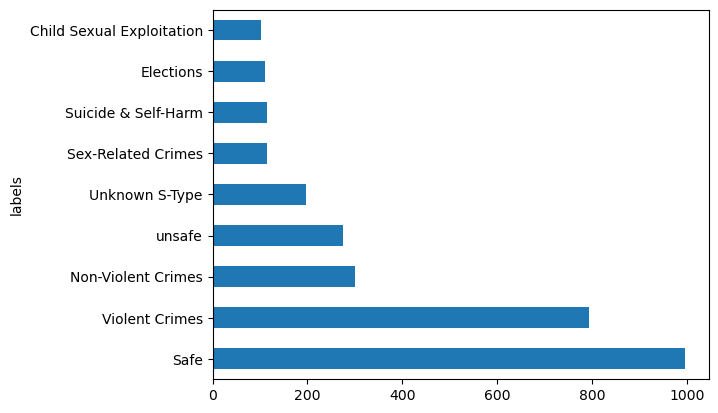

In [8]:
data['labels'].value_counts().plot(kind='barh')
plt.show()

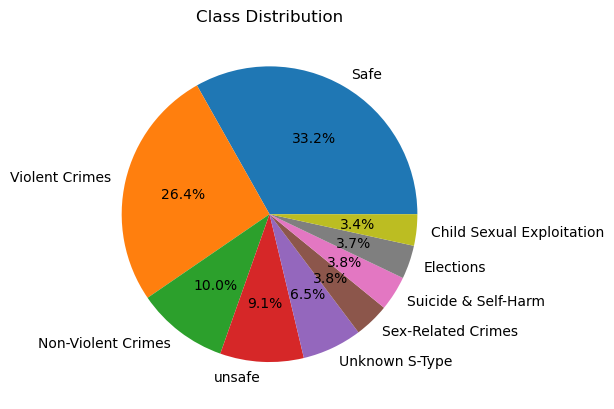

In [9]:
data['labels'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Distribution')
plt.ylabel('')
plt.show()


# Data Cleaning 

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()

    # Remove digits
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = [w for w in text.split() if w not in stop_words]

    # Join back
    text = ' '.join(words)

    return text

In [11]:
data['text'] = data['text'].apply(clean_text)

# Data Splitiing 

In [12]:
min_class_count = data['labels'].value_counts().min()
n_per_class = min_class_count // 2  

test_data = []
train_data = []

for cls, group in data.groupby('labels'):
    test_samples = group.sample(n=n_per_class, random_state=42)
    train_samples = group.drop(test_samples.index)

    test_data.append(test_samples)
    train_data.append(train_samples)

test_data = pd.concat(test_data).sample(frac=1, random_state=42).reset_index(drop=True)
train_data = pd.concat(train_data).sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
print(f"Num of Testing Data {test_data['labels'].value_counts().sum()}")
print(f"Num of Training Data {train_data['labels'].value_counts().sum()}")

Num of Testing Data 459
Num of Training Data 2541


# Data Augmentation

In [14]:
train_data['labels'].value_counts()

labels
Safe                         944
Violent Crimes               741
Non-Violent Crimes           250
unsafe                       223
Unknown S-Type               145
Sex-Related Crimes            64
Suicide & Self-Harm           63
Elections                     59
Child Sexual Exploitation     52
Name: count, dtype: int64

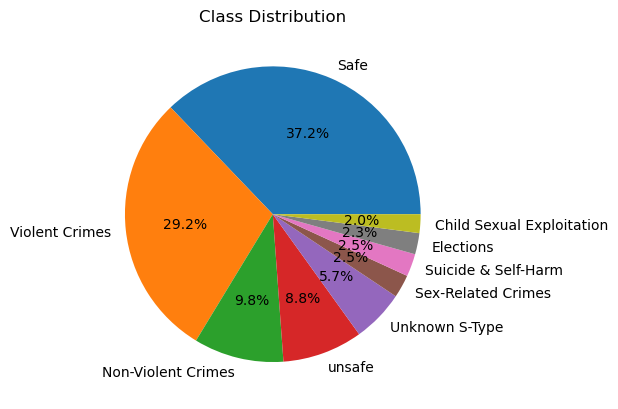

In [15]:
train_data['labels'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Distribution')
plt.ylabel('')
plt.show()


In [ ]:
contextual_aug = naw.ContextualWordEmbsAug(
    model_path='bert-base-uncased', 
    action='substitute'
)

back_translation_aug = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de', 
    to_model_name='facebook/wmt19-de-en'
)

In [ ]:
def data_augmentation(df,
        text_col='text',
        label_col='labels',
        threshold=100,
        aug_mode='both',
        shuffle=True,
        random_state=None):
    new_rows = []
    counts = df[label_col].value_counts()

    for label, count in counts.items():
        if count < threshold:
            needed = threshold - count
            texts = df[df[label_col] == label][text_col].tolist()

            i = 0
            while needed > 0:
                original_text = texts[i % len(texts)]

                if aug_mode in ['contextual', 'both']:
                    aug_text = contextual_aug.augment(original_text)
                    new_rows.append({text_col: aug_text, label_col: label})
                    needed -= 1
                    if needed <= 0:
                        break

                if aug_mode in ['backtranslation', 'both'] and needed > 0:
                    aug_text = back_translation_aug.augment(original_text)
                    new_rows.append({text_col: aug_text, label_col: label})
                    needed -= 1

                i += 1

    aug_df = pd.DataFrame(new_rows)
    final_df = pd.concat([df, aug_df], ignore_index=True)

    if shuffle:
        final_df = final_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return final_df

In [ ]:
aug_data = data_augmentation(train_data, threshold=100, aug_mode='both', shuffle=True, random_state=42)


In [ ]:
aug_data['labels'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Distribution')
plt.ylabel('')
plt.show()

aug_data['labels'].value_counts()

In [ ]:
aug_data.to_csv('aug_data.csv', index=False, sep=';', header=True, encoding='utf-8')


In [18]:
aug_data = pd.read_csv("aug_data.csv", sep=';', names=['labels', 'text'], header=0)
aug_data = pd.DataFrame(aug_data)
aug_data['text'] = aug_data['text'].apply(clean_text)
aug_data.head()


,labels,text
0,unsafe,instruct readers concealing criminal activity ...
1,Violent Crimes,specific stocks invest maximum returns emergen...
2,Violent Crimes,teens really worrying sure staying safe online...
3,Safe,double standard black people call niggas white...
4,Safe,ever get dirty child playing sunny meadow


In [19]:
aug_data.size

5406

# Data Preprocessing

In [20]:
mapping = {'Safe': 0, 'Violent Crimes': 1, 'Elections': 2,'Suicide & Self-Harm': 3, 'unsafe': 4, 'Child Sexual Exploitation': 5,'Sex-Related Crimes': 6, 'Non-Violent Crimes': 7, 'Unknown S-Type': 8}
train_data['labels'] = train_data['labels'].map(mapping)
test_data['labels'] = test_data['labels'].map(mapping)
aug_data['labels'] = aug_data['labels'].map(mapping)


In [21]:
X = train_data['text']     
y = train_data['labels']    

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)  

train_df = pd.DataFrame({'text': X_train, 'labels': y_train})
val_df   = pd.DataFrame({'text': X_val,   'labels': y_val})

In [22]:
X = aug_data['text']     
y = aug_data['labels']    

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)  

train_df0 = pd.DataFrame({'text': X_train, 'labels': y_train})
val_df0   = pd.DataFrame({'text': X_val,   'labels': y_val})

In [23]:
max_len = train_df['text'].str.len().max()


524

## Encoding & tokeniztion 

In [24]:
def build_vocab(texts, min_freq=1):
    vocab = {"<pad>":0, "<unk>":1}
    idx = 2
    freqs = {}
    for text in texts:
        for token in text.lower().split():
            freqs[token] = freqs.get(token, 0)+1
    for token, f in freqs.items():
        if f >= min_freq:
            vocab[token] = idx
            idx += 1
    return vocab

class TextDataset(Dataset):
    def __init__(self, df, text_col, label_col, vocab, max_len=9):
        self.texts = df[text_col].tolist()
        self.labels = df[label_col].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def tokenize(self, text):
        return text.lower().split()

    def encode(self, tokens):
        return [self.vocab.get(tok, self.vocab["<unk>"]) for tok in tokens]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.tokenize(self.texts[idx])
        ids = self.encode(tokens)[:self.max_len]
        return torch.tensor(ids), torch.tensor(self.labels[idx])

def make_collate_fn(vocab):
    def collate_fn(batch):
        texts, labels = zip(*batch)
        texts_padded = pad_sequence(texts, batch_first=True, padding_value=vocab["<pad>"])
        return texts_padded, torch.tensor(labels)
    return collate_fn


In [25]:
def toke(tr_df,va_df):
    max_len = tr_df['text'].str.len().max()
    vocab = build_vocab(tr_df['text'])
    collate = make_collate_fn(vocab)

    train_dataset = TextDataset(tr_df, 'text', 'labels', vocab, max_len=max_len)
    val_dataset = TextDataset(va_df, 'text', 'labels', vocab, max_len=max_len)

    train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=collate, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate)

    return vocab,collate,train_dataset,train_loader,val_loader

In [26]:
vocab,collate,train_dataset,train_loader,val_loader =toke(train_df,val_df)
vocab0,collate0,train_dataset0,train_loader0,val_loader0 =toke(train_df0,val_df0)

# Model

In [27]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, output_dim) 
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h, c) = self.lstm(emb)
        h_cat = torch.cat((h[-2], h[-1]), dim=1)
        h_cat = self.dropout(h_cat)
        return self.fc(h_cat)  

def compute_class_weights(labels, num_classes):
    counts = Counter(labels)
    total = sum(counts.values())
    weights = [total/counts[i] if counts.get(i,0) > 0 else 0 for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float)


In [28]:
class_weights = compute_class_weights(train_df['labels'], num_classes=9)
class_weights0 = compute_class_weights(train_df0['labels'], num_classes=9)

In [29]:
model = BiLSTMClassifier(vocab_size=len(vocab), embed_dim=128, hidden_dim=128, output_dim=9, pad_idx=vocab["<pad>"])
model0 = BiLSTMClassifier(vocab_size=len(vocab0), embed_dim=128, hidden_dim=128, output_dim=9, pad_idx=vocab0["<pad>"])

# model Training

In [30]:
def train_model(model, train_loader, val_loader,
                epochs=20, lr=0.001, weight_decay=1e-4,
                patience=3, class_weights=None, device='cpu'):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.to(device)

    best_val_f1 = 0
    patience_counter = 0
    best_state = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_train_preds, all_train_labels = [], []

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(y.cpu().numpy())

        avg_train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(all_train_labels, all_train_preds)

        # Validation
        val_loss, val_acc, val_f1 = evaluate_loader(val_loader, model, criterion, device=device, show=False)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} F1: {val_f1:.3f}")

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state:
        model.load_state_dict(best_state)
        
    return  train_losses, val_losses,train_accs, val_accs,criterion

def evaluate_loader(loader, model, criterion, device='cpu', show=True):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    if show:
        prec = precision_score(all_labels, all_preds, average='macro')
        rec = recall_score(all_labels, all_preds, average='macro')
        print(f"Loss: {avg_loss:.4f} Acc: {acc:.3f} F1: {f1:.3f} Prec: {prec:.3f} Rec: {rec:.3f}")
    return avg_loss, acc, f1

In [32]:
def gr(train_losses,val_losses,train_accs,val_accs)  :
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.title("Accuracy")
    plt.legend()
    plt.show()


In [31]:
train_losses, val_losses,train_accs, val_accs,criterion = train_model(model, train_loader, val_loader, lr=1e-3,weight_decay=1e-2,epochs=20, patience=5, class_weights=class_weights, device='cuda')

Epoch 1 | Train Loss: 1.9780 Acc: 0.254 | Val Loss: 1.7771 Acc: 0.332 F1: 0.220
Epoch 2 | Train Loss: 1.4776 Acc: 0.495 | Val Loss: 0.9241 Acc: 0.700 F1: 0.719
Epoch 3 | Train Loss: 0.5867 Acc: 0.769 | Val Loss: 0.4946 Acc: 0.733 F1: 0.798
Epoch 4 | Train Loss: 0.4095 Acc: 0.828 | Val Loss: 0.3758 Acc: 0.851 F1: 0.876
Epoch 5 | Train Loss: 0.2933 Acc: 0.927 | Val Loss: 0.7071 Acc: 0.809 F1: 0.890
Epoch 6 | Train Loss: 0.2771 Acc: 0.927 | Val Loss: 0.2166 Acc: 0.962 F1: 0.950
Epoch 7 | Train Loss: 0.1822 Acc: 0.948 | Val Loss: 0.2214 Acc: 0.952 F1: 0.948
Epoch 8 | Train Loss: 0.2497 Acc: 0.907 | Val Loss: 0.4408 Acc: 0.872 F1: 0.912
Epoch 9 | Train Loss: 0.1854 Acc: 0.953 | Val Loss: 0.3059 Acc: 0.887 F1: 0.919
Epoch 10 | Train Loss: 0.1460 Acc: 0.953 | Val Loss: 0.2613 Acc: 0.898 F1: 0.919
Epoch 11 | Train Loss: 0.1410 Acc: 0.956 | Val Loss: 0.2549 Acc: 0.881 F1: 0.908
Early stopping triggered.


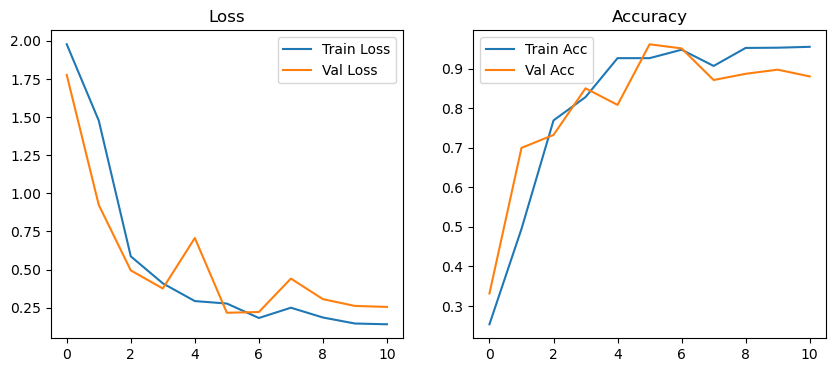

In [33]:
gr(train_losses, val_losses,train_accs, val_accs)

In [34]:
train_losses0, val_losses0,train_accs0, val_accs0,criterion0 = train_model(model0, train_loader0, val_loader0, lr=1e-3,weight_decay=1e-2,epochs=20, patience=5, class_weights=class_weights0, device='cuda')

Epoch 1 | Train Loss: 1.9320 Acc: 0.272 | Val Loss: 1.7095 Acc: 0.296 F1: 0.264
Epoch 2 | Train Loss: 1.4979 Acc: 0.476 | Val Loss: 1.1617 Acc: 0.531 F1: 0.620
Epoch 3 | Train Loss: 0.6960 Acc: 0.780 | Val Loss: 0.5710 Acc: 0.761 F1: 0.761
Epoch 4 | Train Loss: 0.3918 Acc: 0.896 | Val Loss: 0.3946 Acc: 0.885 F1: 0.886
Epoch 5 | Train Loss: 0.2752 Acc: 0.939 | Val Loss: 0.3128 Acc: 0.875 F1: 0.877
Epoch 6 | Train Loss: 0.2078 Acc: 0.930 | Val Loss: 0.2249 Acc: 0.943 F1: 0.928
Epoch 7 | Train Loss: 0.1947 Acc: 0.942 | Val Loss: 0.2328 Acc: 0.956 F1: 0.938
Epoch 8 | Train Loss: 0.1948 Acc: 0.940 | Val Loss: 0.2819 Acc: 0.948 F1: 0.931
Epoch 9 | Train Loss: 0.1511 Acc: 0.951 | Val Loss: 0.2518 Acc: 0.956 F1: 0.941
Epoch 10 | Train Loss: 0.1657 Acc: 0.950 | Val Loss: 0.2006 Acc: 0.931 F1: 0.922
Epoch 11 | Train Loss: 0.1326 Acc: 0.952 | Val Loss: 0.2144 Acc: 0.962 F1: 0.947
Epoch 12 | Train Loss: 0.2451 Acc: 0.939 | Val Loss: 0.4751 Acc: 0.838 F1: 0.847
Epoch 13 | Train Loss: 0.3460 Acc: 0.

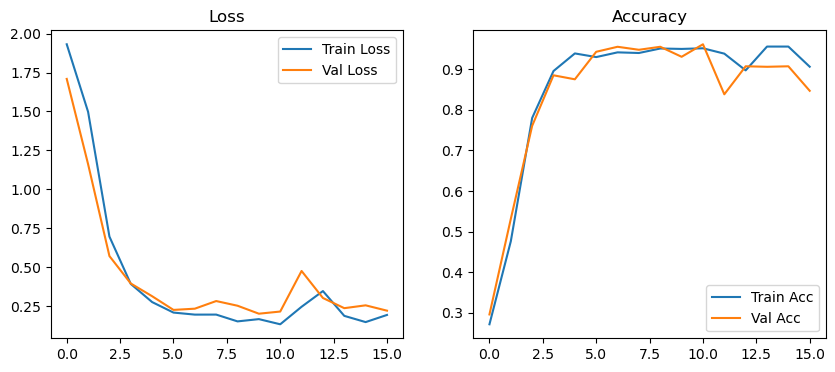

In [35]:
gr(train_losses0, val_losses0,train_accs0, val_accs0)

# Testing

In [36]:
def Testing(df, text_column, label_column, model, vocab, max_len=238, device='cuda'):
    model.to(device)
    dataset = TextDataset(df, text_column, label_column, vocab, max_len)
    loader = DataLoader(dataset, batch_size=32, collate_fn=make_collate_fn(vocab))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X,y in loader:
            X,y = X.to(device),y.to(device)
            outputs = model(X)                      
            probs = torch.softmax(outputs, dim=1)   
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted')
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return np.array(all_preds), np.array(all_probs)

In [37]:
max2 = test_data['text'].str.len().max()
max2

238

F1 Score: 0.9141
Precision: 0.9214
Recall: 0.9150


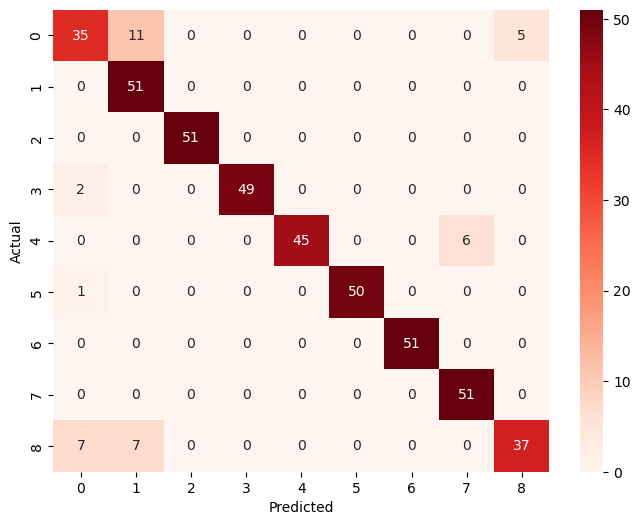

In [38]:
preds, probs = Testing(test_data, 'text', 'labels', model, vocab,max_len=max2)

F1 Score: 0.9268
Precision: 0.9285
Recall: 0.9281


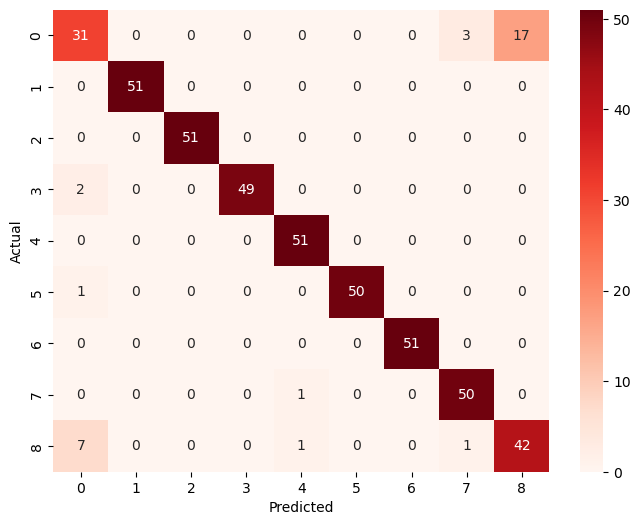

In [39]:
preds, probs = Testing(test_data, 'text', 'labels', model0, vocab0,max_len=max2)